## Assessing cell type and disease specificity of target gene expression in hPCLS

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import sc_toolbox as sct

Running Scanpy 1.8.2, on 2024-09-10 12:12.


In [2]:
## path variables
adata_dir = '/home/niklas/data/220107_Human_PCLS_ASK_joint/220107_PCLS_human_ASK_joint_annotated_NIKLAS.h5ad'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig2/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

In [5]:
## target gene dict
target_dict = {'Nintedanib' : ['FLT1', 'KDR', 'FLT4', 'FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'PDGFA', 'PDGFB'], # Nintedanib 
           'GLPG1205' : ['GPR84'],
           'GLPG1690' : ['ENPP2'],
          }

In [6]:
## target gene list
target_list = ['FLT1', 'KDR', 'FLT4', 'FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'PDGFA', 'PDGFB', 'GPR84','ENPP2']

### Rename some cell types

In [7]:
ct_rename = {
    'Aberrant Basaloid' : 'KRT17+/KRT5- Basaloid',
    'Myofibroblasts' : 'CTHRC1+ Myofibroblasts',
    'ectopic EC' : 'VWA1+/PLVAP+ ectopic EC',
    'Profibrotic Macrophages' : 'SPP1+ Macrophages',   
}
#[ for ct_old, ct_new in ct_rename]
adata.obs['cell_type'] = adata.obs['cell_type'].replace(ct_rename)

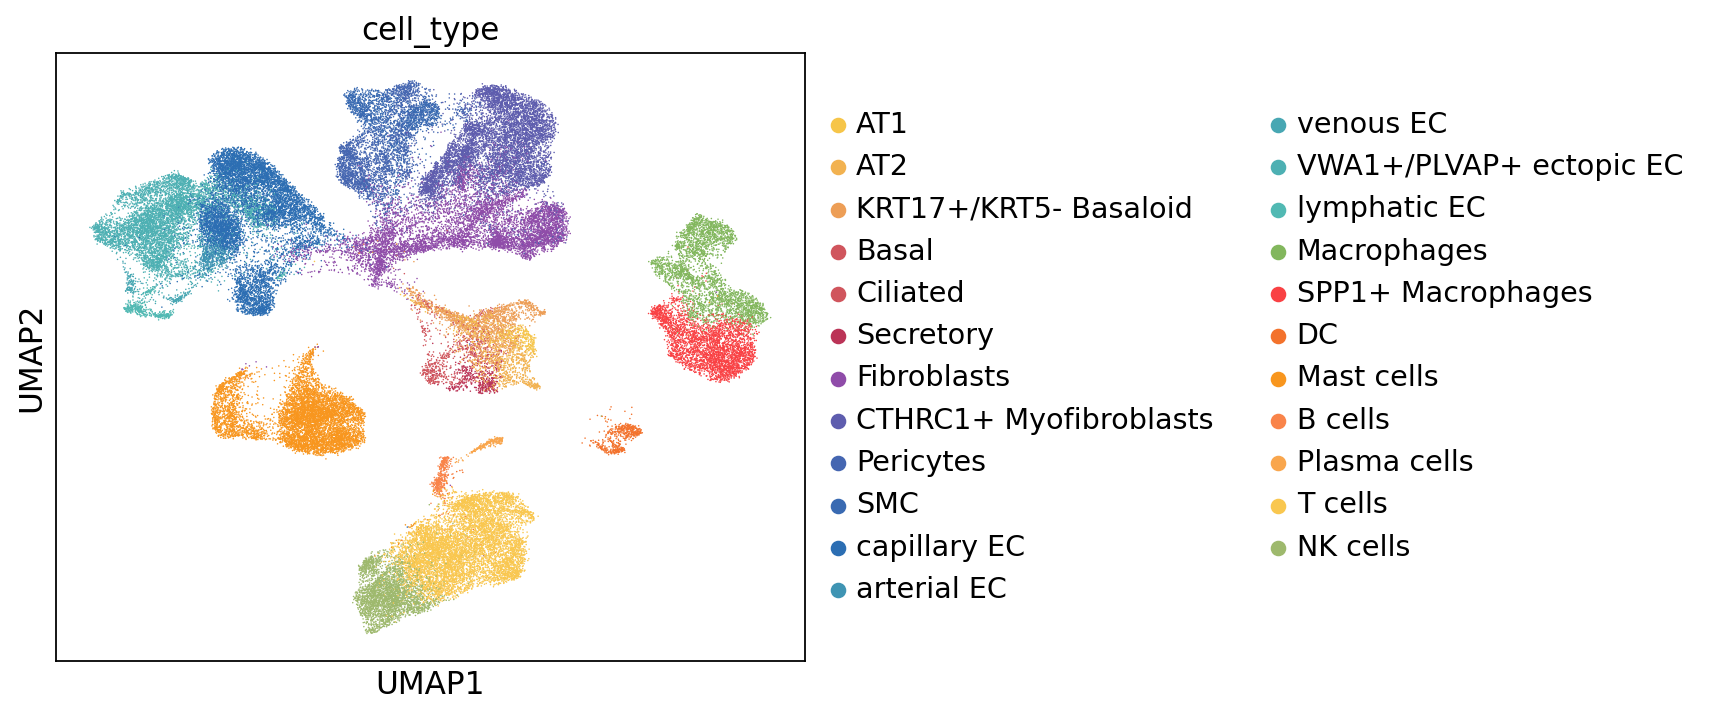

In [8]:
## reorder treatment labels
adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
adata.obs['cell_type'] = adata.obs['cell_type'].cat.reorder_categories(['AT1',
                                                                        'AT2',
                                                                        'KRT17+/KRT5- Basaloid',
                                                                        'Basal',
                                                                        'Ciliated',
                                                                        'Secretory',
                                                                        
                                                                        'Fibroblasts',
                                                                        'CTHRC1+ Myofibroblasts',
                                                                        'Pericytes',
                                                                        'SMC',
                                                                        
                                                                        'capillary EC',
                                                                        'arterial EC',
                                                                        'venous EC',
                                                                        'VWA1+/PLVAP+ ectopic EC',
                                                                        'lymphatic EC',
                                                                        
                                                                        #'Monocytes',
                                                                        'Macrophages',
                                                                        'SPP1+ Macrophages',
                                                                        'DC',
                                                                        
                                                                        'Mast cells',
                                                                        
                                                                        'B cells',
                                                                        'Plasma cells',
                                                                        'T cells',
                                                                        'NK cells'
                                                                        ])
sc.pl.umap(adata, color = 'cell_type')

In [9]:
## subset adata to cat relevant for baseline assessment
adata = adata[adata.obs['treatment'].isin(['CC','FC'])].copy()

### Assess cell type specificity

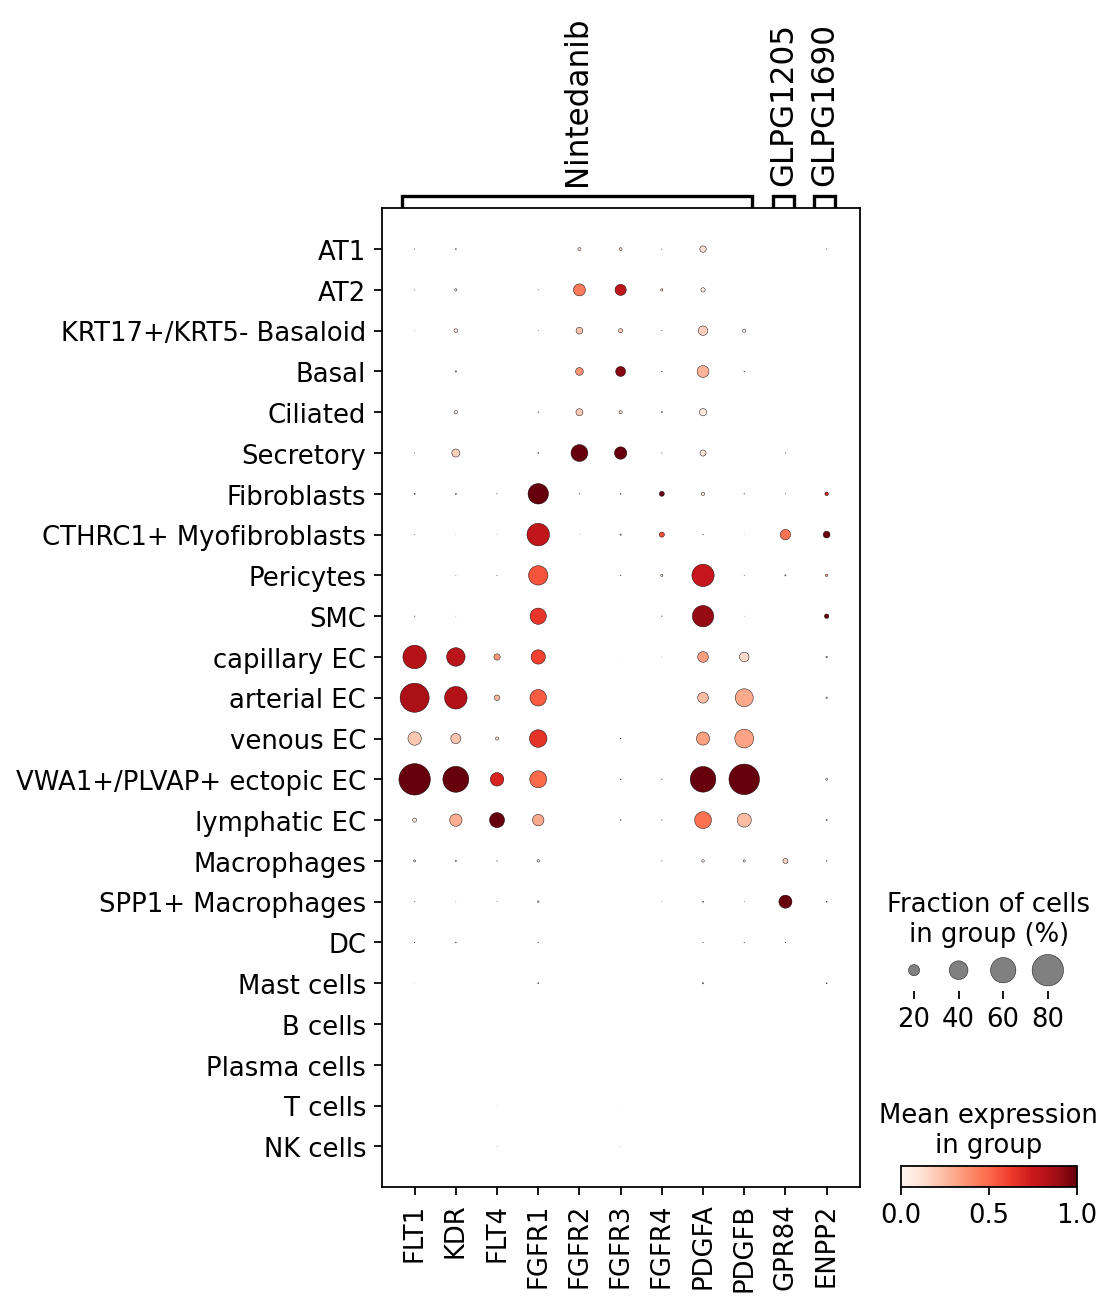

In [10]:
sc.pl.dotplot(adata, target_dict,
              'cell_type',
              standard_scale = 'var',
              cmap = 'Reds',
              dot_max = 0.8,
              save = 'hPCLS_cell_type_specificity.pdf')

In [11]:
adata.obs.cell_type.cat.categories

Index(['AT1', 'AT2', 'KRT17+/KRT5- Basaloid', 'Basal', 'Ciliated', 'Secretory',
       'Fibroblasts', 'CTHRC1+ Myofibroblasts', 'Pericytes', 'SMC',
       'capillary EC', 'arterial EC', 'venous EC', 'VWA1+/PLVAP+ ectopic EC',
       'lymphatic EC', 'Macrophages', 'SPP1+ Macrophages', 'DC', 'Mast cells',
       'B cells', 'Plasma cells', 'T cells', 'NK cells'],
      dtype='object')

### Assess disease specificity

In [12]:
## calculate log2FC for all genes
sc.tl.rank_genes_groups(adata, 
                        groupby ='treatment',
                        mask_var = target_list,
                        method = 'wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:27)


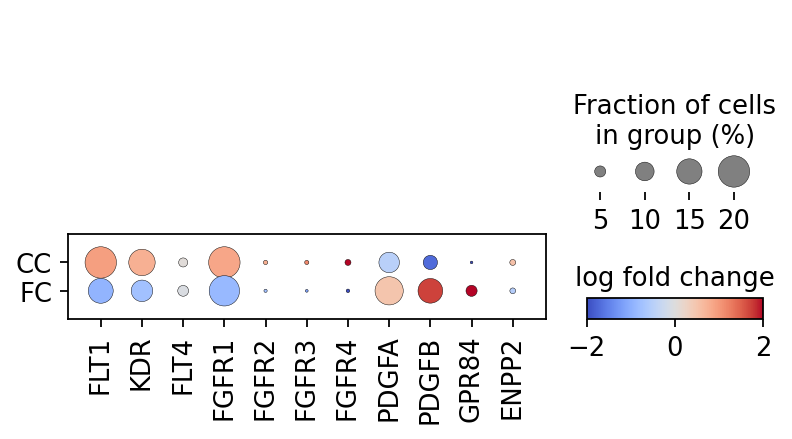

In [13]:
sc.pl.rank_genes_groups_dotplot(adata,
                                groupby='treatment',
                                var_names = target_list, 
                                values_to_plot='logfoldchanges',
                                dot_max = 0.2,
                                vmax=2,
                                vmin=-2,
                                cmap = 'coolwarm',
                                dendrogram = False,
                                save = 'hPCLS_disease_specificity.pdf')